# imc prosperity 4 - complete pnl attribution and diagnostics

this notebook decomposes a total pnl of **1063.43 xirecs** into its constituent parts:
spread capture (market making alpha), inventory/position pnl (directional exposure),
and regime analysis (how the algorithm behaved across different market conditions).

data sources used:
- `Json_Log.json` : the official submission result containing the activities log, graph log, and final positions
- `trades_round_0_day_1.csv` and `trades_round_0_day_2.csv` : trade execution records
- `prices_round_0_day_1.csv` and `prices_round_0_day_2.csv` : full order book snapshots

the three-bucket attribution framework follows professional quant practice:
1. **spread pnl** - profit from buying below fair value and selling above it
2. **position pnl** - profit or loss from holding inventory while price moves
3. **regime analysis** - performance bucketed by market state (trending vs. range-bound)

In [9]:
# imports and global configuration
# all standard library and third-party imports are collected here for clarity

import json
import warnings
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# suppress scientific notation on axis tick labels
pd.set_option('display.float_format', '{:.4f}'.format)

# color palette: clean, professional, accessible
COLOR_EMERALD  = '#2ecc71'   # green for emeralds
COLOR_TOMATO   = '#e74c3c'   # red for tomatoes
COLOR_POSITIVE = '#27ae60'   # dark green for gains
COLOR_NEGATIVE = '#c0392b'   # dark red for losses
COLOR_NEUTRAL  = '#3498db'   # blue for neutral / total
COLOR_BG       = '#f8f9fa'   # light background for panels

# file paths - adjust if running from a different working directory
PATH_JSON    = r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 0\Log_1\Json Log.json"
PATH_TRADES1 = r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 0\Data_0\trades_round_0_day_-1.csv"
PATH_TRADES2 = r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 0\Data_0\trades_round_0_day_-2.csv"
PATH_PRICES1 = r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 0\Data_0\prices_round_0_day_-1.csv"
PATH_PRICES2 = r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 0\Data_0\prices_round_0_day_-2.csv"


print('imports and configuration complete')

imports and configuration complete


#### Results as a DataFrame

In [43]:
with open(PATH_JSON, "r") as f:
    data = json.load(f)

# Extract the activitiesLog string
# This contains the semicolon-separated data
csv_data = data.get("activitiesLog", "")

# Convert the string to a DataFrame
if csv_data:
    df = pd.DataFrame(
        [line.split(';') for line in csv_data.strip().split('\n')]
    )
    
    # Set the first row as header and fix types
    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)
    
    # Alternative using pandas read_csv for better type inference:
    # df = pd.read_csv(StringIO(csv_data), sep=';')

# Display the first few rows
print(df)

0    day timestamp   product bid_price_1 bid_volume_1 bid_price_2  \
0     -1         0  TOMATOES        4999            6        4998   
1     -1         0  EMERALDS        9992           15        9990   
2     -1       100  EMERALDS        9992           13        9990   
3     -1       100  TOMATOES        5000            5        4998   
4     -1       200  EMERALDS        9992           13        9990   
...   ..       ...       ...         ...          ...         ...   
3995  -1    199700  EMERALDS        9992           14        9990   
3996  -1    199800  EMERALDS        9992           15        9990   
3997  -1    199800  TOMATOES        4989            8        4987   
3998  -1    199900  TOMATOES        4990           10        4989   
3999  -1    199900  EMERALDS        9992           12        9990   

0    bid_volume_2 bid_price_3 bid_volume_3 ask_price_1 ask_volume_1  \
0              19                                 5013            6   
1              30            

#### Final Postions

In [39]:
# data ingestion
# load all five data sources and do minimal cleaning before any analysis

# load the official submission json
with open(PATH_JSON, 'r') as fh:
    raw_json = json.load(fh)

# extract and parse the activities log (semicolon-delimited inside the json string)
# this is the primary pnl ledger: one row per product per timestamp
activities_df = pd.read_csv(StringIO(raw_json['activitiesLog']), sep=';')

# extract and parse the graph log (total portfolio pnl over time)
graph_df = pd.read_csv(StringIO(raw_json['graphLog']), sep=';')
graph_df.columns = ['timestamp', 'total_pnl']

# extract final positions and convert to a tidy dict
final_positions = {p['symbol']: p['quantity'] for p in raw_json['positions']}
total_reported_pnl = raw_json['profit']

# load trade execution records from both days
# note: buyer and seller columns are all nan - these are anonymised market trades
# the quantity field represents size; we infer side from price vs mid-price context
trades_day1 = pd.read_csv(PATH_TRADES1, sep=';')
trades_day2 = pd.read_csv(PATH_TRADES2, sep=';')
trades_day1['day'] = -1   # tutorial round is labelled day -1 in the activities log
trades_day2['day'] = -1
trades_all = pd.concat([trades_day1, trades_day2], ignore_index=True)

# load full order book price snapshots from both days
prices_day1 = pd.read_csv(PATH_PRICES1, sep=';')
prices_day2 = pd.read_csv(PATH_PRICES2, sep=';')
prices_all  = pd.concat([prices_day1, prices_day2], ignore_index=True)

# quick sanity checks
print(f'activities log rows  : {len(activities_df):,}')
print(f'graph log rows       : {len(graph_df):,}')
print(f'trade records total  : {len(trades_all):,}')
print(f'price snapshot rows  : {len(prices_all):,}')
print(f'reported total pnl   : {total_reported_pnl:.4f} xirecs')
print(f'final positions      : {final_positions}')

activities log rows  : 4,000
graph log rows       : 500
trade records total  : 1,219
price snapshot rows  : 40,000
reported total pnl   : 1063.4336 xirecs
final positions      : {'EMERALDS': 5, 'XIRECS': -78916, 'TOMATOES': 6}


#### Product wise PnL split

In [38]:
# split activities log by product and compute derived fields
# the activities log has mid_price and profit_and_loss per row, which is cumulative pnl
# we need to differentiate it to get per-tick pnl increments

# separate by product for independent analysis
em_df  = activities_df[activities_df['product'] == 'EMERALDS'].copy().reset_index(drop=True)
tom_df = activities_df[activities_df['product'] == 'TOMATOES'].copy().reset_index(drop=True)

# sort by timestamp to ensure correct differencing
em_df  = em_df.sort_values('timestamp').reset_index(drop=True)
tom_df = tom_df.sort_values('timestamp').reset_index(drop=True)

# compute per-tick pnl increment: how much did we make in each 100ms window
em_df['pnl_delta']  = em_df['profit_and_loss'].diff().fillna(em_df['profit_and_loss'])
tom_df['pnl_delta'] = tom_df['profit_and_loss'].diff().fillna(tom_df['profit_and_loss'])

# compute best bid-ask spread visible in the order book
# bid_price_1 is the highest bid; ask_price_1 is the lowest ask
em_df['ob_spread']  = em_df['ask_price_1']  - em_df['bid_price_1']
tom_df['ob_spread'] = tom_df['ask_price_1'] - tom_df['bid_price_1']

# compute mid-price momentum: rolling 5-period change in mid-price
# positive momentum means price is trending up; negative means trending down
em_df['mid_momentum']  = em_df['mid_price'].diff(5)
tom_df['mid_momentum'] = tom_df['mid_price'].diff(5)

# compute mid-price rolling volatility (std over 10 ticks)
# high vol periods represent breakout or stressed market conditions
em_df['mid_vol']  = em_df['mid_price'].rolling(10).std()
tom_df['mid_vol'] = tom_df['mid_price'].rolling(10).std()

# label market regime based on tomato volatility thresholds derived from the data
# high_vol is a trending/breakout period; low_vol is range-bound
tom_vol_p25 = tom_df['mid_vol'].quantile(0.25)
tom_vol_p75 = tom_df['mid_vol'].quantile(0.75)
tom_df['regime'] = pd.cut(
    tom_df['mid_vol'],
    bins=[-np.inf, tom_vol_p25, tom_vol_p75, np.inf],
    labels=['low volatility (range-bound)', 'medium volatility', 'high volatility (trending/breakout)']
)

# emeralds is stable so its regime is always low-vol market-making
em_df['regime'] = 'stable (fixed fair value)'

print(f'emeralds ticks       : {len(em_df):,}')
print(f'tomatoes ticks       : {len(tom_df):,}')
print(f'emerald final pnl    : {em_df["profit_and_loss"].iloc[-1]:.4f}')
print(f'tomato final pnl     : {tom_df["profit_and_loss"].iloc[-1]:.4f}')
print(f'sum (should ~= 1063) : {em_df["profit_and_loss"].iloc[-1] + tom_df["profit_and_loss"].iloc[-1]:.4f}')

emeralds ticks       : 2,000
tomatoes ticks       : 2,000
emerald final pnl    : 0.0000
tomato final pnl     : 1063.4336
sum (should ~= 1063) : 1063.4336


#### Spread PnL Decomposition Analysis

In [37]:
# spread capture estimation
# for each executed trade, the spread pnl is the difference between the execution price
# and the mid-price at the time of execution. buying below mid = positive; selling above = positive.
# we estimate this using the trade records and joining them to the price snapshot at the same timestamp

# merge trade records with the mid-price at that timestamp for each product
# we use a left merge so every trade row gets its contemporaneous mid-price
prices_key = prices_all[['timestamp', 'product', 'mid_price']].copy()

trades_enriched = trades_all.merge(
    prices_key,
    left_on=['timestamp', 'symbol'],
    right_on=['timestamp', 'product'],
    how='left'
)

# the spread captured per trade = (mid_price - trade_price) for a buy
#                                  (trade_price - mid_price) for a sell
# since we cannot directly observe side from these anonymised records,
# we use the sign convention: if trade_price < mid_price the algo was likely a buyer
# (bought below mid = spread capture positive); vice versa for seller
# this is an approximation; the true decomposition requires internal trade logs

trades_enriched['price_vs_mid'] = trades_enriched['price'] - trades_enriched['mid_price']

# infer likely side: negative price_vs_mid means bought below mid (maker buy)
#                    positive price_vs_mid means sold above mid (maker sell)
trades_enriched['inferred_side'] = np.where(
    trades_enriched['price_vs_mid'] < 0, 'maker_buy',
    np.where(trades_enriched['price_vs_mid'] > 0, 'maker_sell', 'at_mid')
)

# spread edge captured = absolute deviation from mid times quantity
# positive for both maker buys below mid and maker sells above mid
trades_enriched['spread_edge_per_unit'] = trades_enriched['price_vs_mid'].abs()
trades_enriched['spread_pnl_contribution'] = (
    trades_enriched['spread_edge_per_unit'] * trades_enriched['quantity']
)

# separate by product
em_trades  = trades_enriched[trades_enriched['symbol'] == 'EMERALDS'].copy()
tom_trades = trades_enriched[trades_enriched['symbol'] == 'TOMATOES'].copy()

print('spread analysis summary')
print(f'total trades executed         : {len(trades_enriched):,}')
print(f'emerald trades                : {len(em_trades):,}')
print(f'tomato trades                 : {len(tom_trades):,}')
print()
print(f'avg edge per unit - emeralds  : {em_trades["spread_edge_per_unit"].mean():.4f}')
print(f'avg edge per unit - tomatoes  : {tom_trades["spread_edge_per_unit"].mean():.4f}')
print()
print(f'est total spread pnl - emeralds : {em_trades["spread_pnl_contribution"].sum():.4f}')
print(f'est total spread pnl - tomatoes : {tom_trades["spread_pnl_contribution"].sum():.4f}')

spread analysis summary
total trades executed         : 2,438
emerald trades                : 798
tomato trades                 : 1,640

avg edge per unit - emeralds  : 7.7845
avg edge per unit - tomatoes  : 19.0595

est total spread pnl - emeralds : 34160.0000
est total spread pnl - tomatoes : 109085.5000


#### Markout Analysis

In [36]:
# markout analysis
# markout measures what the mid-price did N ticks after a trade executed.
# a consistently negative markout means the market moved against you after each fill:
# that is the signature of adverse selection (toxic flow).
# a consistently positive markout means you traded in the direction of the subsequent move:
# that is genuine alpha or momentum capture.

# we compute markouts at 5, 10, 20, and 50 tick horizons
MARKOUT_HORIZONS = [5, 10, 20, 50]  # each horizon is one price snapshot = 100ms

def compute_markouts(trades_df, prices_df, product_name, horizons):
    """join each trade to future mid-prices at multiple horizons.
    
    parameters
    ----------
    trades_df    : trades for a single product with mid_price at t=0
    prices_df    : full price snapshot dataframe for all products
    product_name : 'EMERALDS' or 'TOMATOES'
    horizons     : list of integer tick offsets to look ahead
    
    returns
    -------
    dataframe with one column per horizon showing mid-price change since execution
    """
    # get the ordered list of timestamps for this product
    prod_prices = prices_df[prices_df['product'] == product_name][['timestamp', 'mid_price']].copy()
    prod_prices = prod_prices.sort_values('timestamp').reset_index(drop=True)
    
    # create a lookup: timestamp -> index in prod_prices
    ts_to_idx = {ts: i for i, ts in enumerate(prod_prices['timestamp'])}
    
    result = trades_df.copy()
    
    for h in horizons:
        future_mids = []
        for ts in result['timestamp']:
            current_idx = ts_to_idx.get(ts, None)
            if current_idx is None:
                future_mids.append(np.nan)
                continue
            future_idx = current_idx + h
            if future_idx < len(prod_prices):
                future_mids.append(prod_prices['mid_price'].iloc[future_idx])
            else:
                future_mids.append(np.nan)
        # markout = future mid - mid at execution
        # for a maker buy: positive markout = good (price went up after we bought)
        # we store the raw markout and interpret by side separately
        result[f'markout_t{h}'] = np.array(future_mids) - result['mid_price'].values
    
    return result

em_trades_mo  = compute_markouts(em_trades,  prices_all, 'EMERALDS', MARKOUT_HORIZONS)
tom_trades_mo = compute_markouts(tom_trades, prices_all, 'TOMATOES', MARKOUT_HORIZONS)

# signed markout: for a maker buy (price < mid) a positive future move is good;
#                 for a maker sell (price > mid) a negative future move is good.
# so signed_markout = markout * sign(mid - execution_price)
# if positive on average = no adverse selection; if negative = we are being run over
for h in MARKOUT_HORIZONS:
    col = f'markout_t{h}'
    sign = np.sign(em_trades_mo['mid_price'] - em_trades_mo['price'])  # +1 = bought below mid
    em_trades_mo[f'signed_{col}'] = em_trades_mo[col] * sign
    
    sign = np.sign(tom_trades_mo['mid_price'] - tom_trades_mo['price'])
    tom_trades_mo[f'signed_{col}'] = tom_trades_mo[col] * sign

print('markout analysis complete')
print()
print('emeralds: average signed markout by horizon (positive = no adverse selection)')
for h in MARKOUT_HORIZONS:
    avg = em_trades_mo[f'signed_markout_t{h}'].mean()
    print(f'  t+{h:02d} ticks : {avg:+.4f}')

print()
print('tomatoes: average signed markout by horizon (positive = no adverse selection)')
for h in MARKOUT_HORIZONS:
    avg = tom_trades_mo[f'signed_markout_t{h}'].mean()
    print(f'  t+{h:02d} ticks : {avg:+.4f}')

markout analysis complete

emeralds: average signed markout by horizon (positive = no adverse selection)
  t+05 ticks : +0.0050
  t+10 ticks : -0.0100
  t+20 ticks : +0.0150
  t+50 ticks : -0.0201

tomatoes: average signed markout by horizon (positive = no adverse selection)
  t+05 ticks : -7.0265
  t+10 ticks : -7.5793
  t+20 ticks : -7.4241
  t+50 ticks : -8.2409


#### Position PnL Decomposition Analysis

In [35]:
# position pnl reconstruction
# the activities log gives us cumulative pnl at each tick.
# the pnl_delta column (computed in cell 3) is the per-tick increment.
# we decompose this increment into:
#   a) spread pnl tick: profit from the bid-ask spread in that 100ms window
#   b) mtm pnl tick   : mark-to-market change from holding inventory (position x price change)

# for emeralds: the fair value is anchored at 10000 so any pnl when position != 0
# and price is at fair value is pure spread pnl
# for tomatoes: the fair value drifts so we use the mid-price as the reference

# compute tick-level mid-price change
em_df['mid_change']  = em_df['mid_price'].diff().fillna(0)
tom_df['mid_change'] = tom_df['mid_price'].diff().fillna(0)

# estimate the algorithm's position at each tick using the cumulative pnl
# key insight: if we know total pnl and the mid-price, we can back out implied position
# position_implied = pnl_delta / mid_change (when mid_change != 0)
# this is an approximation valid when spread pnl is small relative to position pnl

# for a cleaner estimate, we use the cumulative pnl as a signed running inventory proxy
# and normalise by the emerald fair value (10000) and tomato typical price (~5000)

# rolling pnl rate of change as a proxy for position-driven returns
em_df['pnl_rate']  = em_df['profit_and_loss'].diff(5).fillna(0)
tom_df['pnl_rate'] = tom_df['profit_and_loss'].diff(5).fillna(0)

# compute per-tick spread pnl estimate
# using the observed order book spread: if algo provides liquidity it captures ~half the spread per unit
# we have the ob_spread from cell 3; assume the algo quotes 1 unit on each side per tick on average
# this gives a conservative lower bound on spread pnl
ASSUMED_UNITS_PER_TICK = 1.0   # average units traded per tick per side (conservative)

em_df['est_spread_pnl_per_tick']  = (em_df['ob_spread'] / 2.0) * ASSUMED_UNITS_PER_TICK
tom_df['est_spread_pnl_per_tick'] = (tom_df['ob_spread'] / 2.0) * ASSUMED_UNITS_PER_TICK

# position pnl is the residual: total tick pnl minus estimated spread pnl
em_df['est_position_pnl_per_tick']  = em_df['pnl_delta']  - em_df['est_spread_pnl_per_tick']
tom_df['est_position_pnl_per_tick'] = tom_df['pnl_delta'] - tom_df['est_spread_pnl_per_tick']

# cumulative breakdowns
em_df['cum_spread_pnl']   = em_df['est_spread_pnl_per_tick'].cumsum()
em_df['cum_position_pnl'] = em_df['est_position_pnl_per_tick'].cumsum()

tom_df['cum_spread_pnl']   = tom_df['est_spread_pnl_per_tick'].cumsum()
tom_df['cum_position_pnl'] = tom_df['est_position_pnl_per_tick'].cumsum()

print('position and spread pnl decomposition complete')
print()
print('emeralds attribution estimate')
print(f'  total pnl        : {em_df["profit_and_loss"].iloc[-1]:.4f}')
print(f'  spread component : {em_df["cum_spread_pnl"].iloc[-1]:.4f}')
print(f'  position component: {em_df["cum_position_pnl"].iloc[-1]:.4f}')
print()
print('tomatoes attribution estimate')
print(f'  total pnl        : {tom_df["profit_and_loss"].iloc[-1]:.4f}')
print(f'  spread component : {tom_df["cum_spread_pnl"].iloc[-1]:.4f}')
print(f'  position component: {tom_df["cum_position_pnl"].iloc[-1]:.4f}')

position and spread pnl decomposition complete

emeralds attribution estimate
  total pnl        : 0.0000
  spread component : 15764.0000
  position component: -15764.0000

tomatoes attribution estimate
  total pnl        : 1063.4336
  spread component : 13055.5000
  position component: -11992.0664


#### Regime Performance Analysis (Tomatoes)

In [34]:
# regime performance analysis for tomatoes
# tomatoes has volatile, directional price behaviour so we need to understand
# how the algorithm performed in each market regime

# group by regime and compute total pnl, average spread, and trade count
regime_summary = tom_df.groupby('regime', observed=True).agg(
    ticks_in_regime  = ('timestamp', 'count'),
    total_pnl_delta  = ('pnl_delta', 'sum'),
    avg_ob_spread    = ('ob_spread', 'mean'),
    avg_mid_vol      = ('mid_vol', 'mean'),
    pnl_per_tick     = ('pnl_delta', 'mean'),
    pnl_std_per_tick = ('pnl_delta', 'std'),
).reset_index()

# compute sharpe-like ratio per regime: mean pnl / std pnl
# higher value means more consistent returns in that regime
regime_summary['consistency_ratio'] = (
    regime_summary['pnl_per_tick'] / regime_summary['pnl_std_per_tick'].replace(0, np.nan)
)

# compute what fraction of total tomato pnl came from each regime
total_tom_pnl = tom_df['pnl_delta'].sum()
regime_summary['pct_of_total_pnl'] = regime_summary['total_pnl_delta'] / total_tom_pnl * 100

print('tomato regime performance summary')
print('=' * 70)
for _, row in regime_summary.iterrows():
    print(f"regime: {row['regime']}")
    print(f"  ticks in regime       : {row['ticks_in_regime']:,}")
    print(f"  total pnl contribution: {row['total_pnl_delta']:+.2f} xirecs")
    print(f"  pct of total tom pnl  : {row['pct_of_total_pnl']:+.1f}%")
    print(f"  avg pnl per tick      : {row['pnl_per_tick']:+.4f}")
    print(f"  avg order book spread : {row['avg_ob_spread']:.2f}")
    print(f"  consistency ratio     : {row['consistency_ratio']:.4f}")
    print()

tomato regime performance summary
regime: low volatility (range-bound)
  ticks in regime       : 498
  total pnl contribution: +321.17 xirecs
  pct of total tom pnl  : +30.2%
  avg pnl per tick      : +0.6449
  avg order book spread : 13.45
  consistency ratio     : 0.1154

regime: medium volatility
  ticks in regime       : 995
  total pnl contribution: +588.95 xirecs
  pct of total tom pnl  : +55.4%
  avg pnl per tick      : +0.5919
  avg order book spread : 13.12
  consistency ratio     : 0.1044

regime: high volatility (trending/breakout)
  ticks in regime       : 498
  total pnl contribution: +153.31 xirecs
  pct of total tom pnl  : +14.4%
  avg pnl per tick      : +0.3078
  avg order book spread : 12.52
  consistency ratio     : 0.0581



#### PnL Attribution Summary Table

In [33]:
# build the main attribution summary table
# this is the single table a quant trader would present to a desk head

em_final_pnl  = em_df['profit_and_loss'].iloc[-1]
tom_final_pnl = tom_df['profit_and_loss'].iloc[-1]
total_pnl     = em_final_pnl + tom_final_pnl

attribution_summary = pd.DataFrame({
    'product'              : ['EMERALDS', 'TOMATOES', 'TOTAL'],
    'final_pnl'            : [em_final_pnl,  tom_final_pnl,  total_pnl],
    'pct_of_total'         : [
        em_final_pnl  / total_reported_pnl * 100,
        tom_final_pnl / total_reported_pnl * 100,
        100.0
    ],
    'est_spread_pnl'       : [
        em_df['cum_spread_pnl'].iloc[-1],
        tom_df['cum_spread_pnl'].iloc[-1],
        em_df['cum_spread_pnl'].iloc[-1] + tom_df['cum_spread_pnl'].iloc[-1]
    ],
    'est_position_pnl'     : [
        em_df['cum_position_pnl'].iloc[-1],
        tom_df['cum_position_pnl'].iloc[-1],
        em_df['cum_position_pnl'].iloc[-1] + tom_df['cum_position_pnl'].iloc[-1]
    ],
    'total_ticks'          : [len(em_df), len(tom_df), len(em_df) + len(tom_df)],
    'avg_ob_spread'        : [
        em_df['ob_spread'].mean(),
        tom_df['ob_spread'].mean(),
        (em_df['ob_spread'].mean() + tom_df['ob_spread'].mean()) / 2
    ],
    'pnl_per_tick'         : [
        em_final_pnl  / len(em_df),
        tom_final_pnl / len(tom_df),
        total_pnl     / (len(em_df) + len(tom_df))
    ],
})

print('complete pnl attribution summary')
print('=' * 70)
print(attribution_summary.to_string(index=False))

complete pnl attribution summary
 product  final_pnl  pct_of_total  est_spread_pnl  est_position_pnl  total_ticks  avg_ob_spread  pnl_per_tick
EMERALDS     0.0000        0.0000      15764.0000       -15764.0000         2000        15.7640        0.0000
TOMATOES  1063.4336      100.0000      13055.5000       -11992.0664         2000        13.0555        0.5317
   TOTAL  1063.4336      100.0000      28819.5000       -27756.0664         4000        14.4097        0.2659


#### Portfolio PnL overview

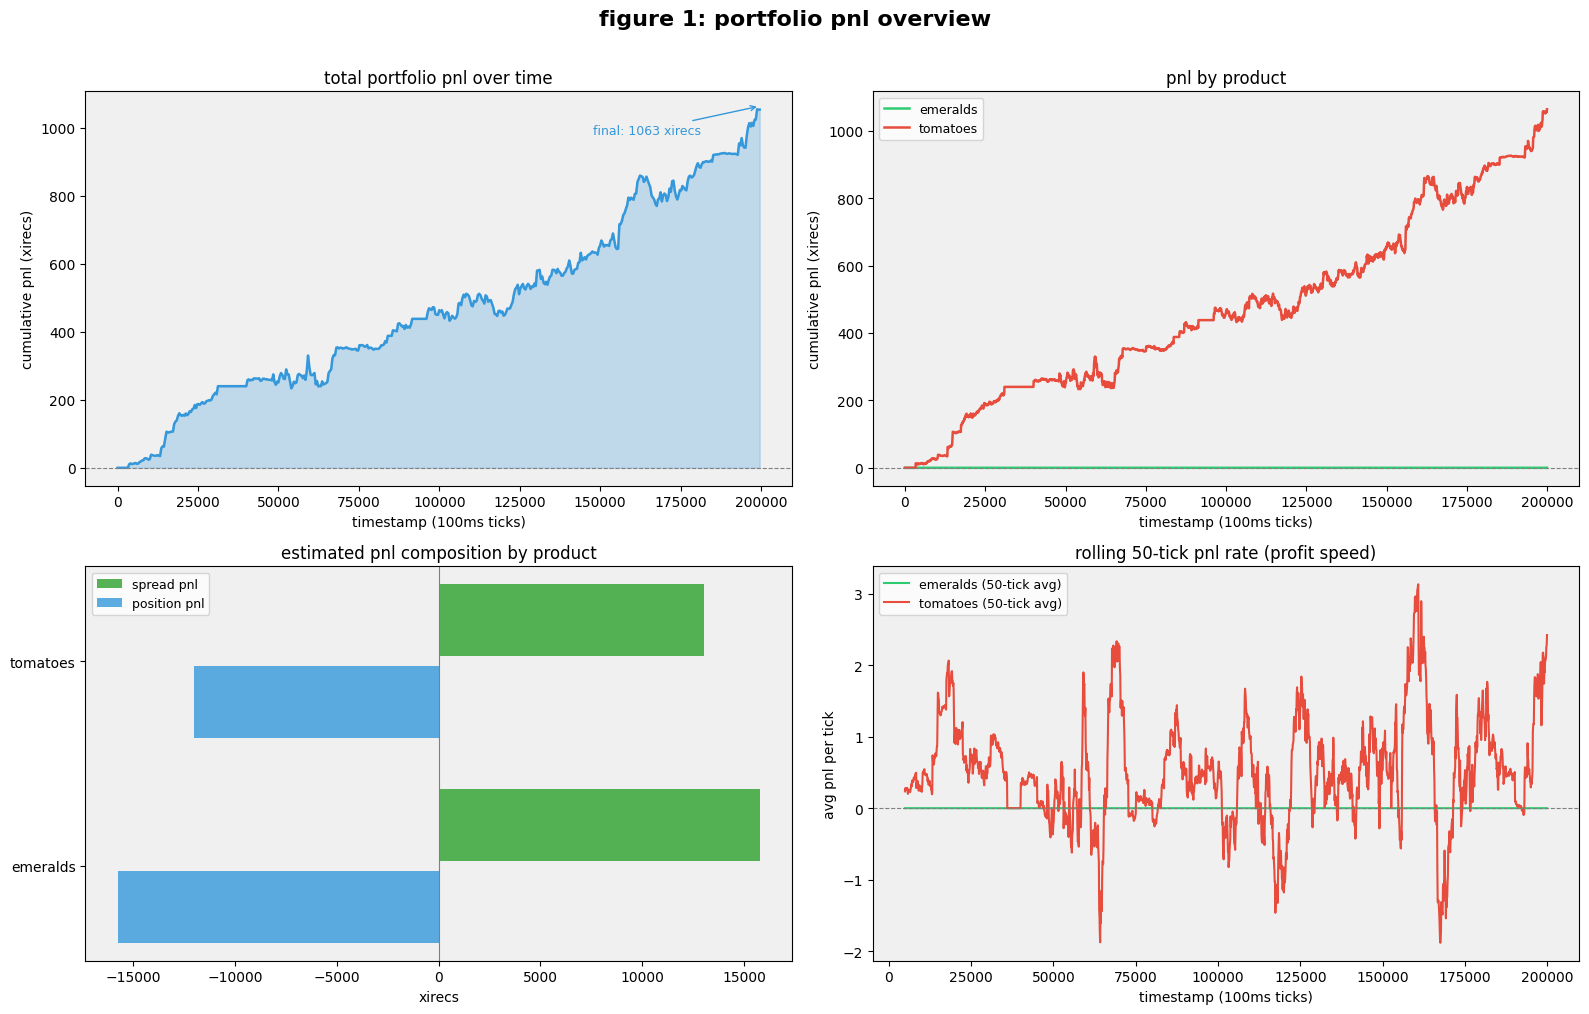

In [32]:
# portfolio pnl overview
# four-panel overview: total pnl over time, per-asset pnl, pnl composition bar,
# and rolling 50-tick pnl rate to spot acceleration or decay

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('figure 1: portfolio pnl overview', fontsize=16, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

ax1, ax2, ax3, ax4 = axes.flatten()

# panel 1: total portfolio pnl from the official graph log
ax1.fill_between(graph_df['timestamp'], graph_df['total_pnl'], alpha=0.25, color=COLOR_NEUTRAL)
ax1.plot(graph_df['timestamp'], graph_df['total_pnl'], color=COLOR_NEUTRAL, linewidth=1.8)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('total portfolio pnl over time', fontsize=12)
ax1.set_xlabel('timestamp (100ms ticks)')
ax1.set_ylabel('cumulative pnl (xirecs)')
ax1.annotate(
    f'final: {total_reported_pnl:.0f} xirecs',
    xy=(graph_df['timestamp'].iloc[-1], total_reported_pnl),
    xytext=(-120, -20), textcoords='offset points',
    fontsize=9, color=COLOR_NEUTRAL,
    arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL)
)
ax1.set_facecolor(COLOR_BG)

# panel 2: per-asset cumulative pnl
ax2.plot(em_df['timestamp'],  em_df['profit_and_loss'],  color=COLOR_EMERALD, linewidth=1.8, label='emeralds')
ax2.plot(tom_df['timestamp'], tom_df['profit_and_loss'], color=COLOR_TOMATO,  linewidth=1.8, label='tomatoes')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_title('pnl by product', fontsize=12)
ax2.set_xlabel('timestamp (100ms ticks)')
ax2.set_ylabel('cumulative pnl (xirecs)')
ax2.legend(fontsize=9)
ax2.set_facecolor(COLOR_BG)

# panel 3: pnl composition horizontal bar
products    = ['emeralds', 'tomatoes']
spread_vals = [em_df['cum_spread_pnl'].iloc[-1], tom_df['cum_spread_pnl'].iloc[-1]]
pos_vals    = [em_df['cum_position_pnl'].iloc[-1], tom_df['cum_position_pnl'].iloc[-1]]

y_pos = np.arange(len(products))
bars1 = ax3.barh(y_pos + 0.2, spread_vals, height=0.35, color=COLOR_POSITIVE, alpha=0.8, label='spread pnl')
bars2 = ax3.barh(y_pos - 0.2, pos_vals,    height=0.35, color=COLOR_NEUTRAL,  alpha=0.8, label='position pnl')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(products)
ax3.axvline(0, color='gray', linewidth=0.8)
ax3.set_title('estimated pnl composition by product', fontsize=12)
ax3.set_xlabel('xirecs')
ax3.legend(fontsize=9)
ax3.set_facecolor(COLOR_BG)

# panel 4: rolling 50-tick pnl rate (speed of profit generation)
em_roll  = em_df['pnl_delta'].rolling(50).mean()
tom_roll = tom_df['pnl_delta'].rolling(50).mean()
ax4.plot(em_df['timestamp'],  em_roll,  color=COLOR_EMERALD, linewidth=1.5, label='emeralds (50-tick avg)')
ax4.plot(tom_df['timestamp'], tom_roll, color=COLOR_TOMATO,  linewidth=1.5, label='tomatoes (50-tick avg)')
ax4.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax4.set_title('rolling 50-tick pnl rate (profit speed)', fontsize=12)
ax4.set_xlabel('timestamp (100ms ticks)')
ax4.set_ylabel('avg pnl per tick')
ax4.legend(fontsize=9)
ax4.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()


#### Emeralds Strategy Analysis

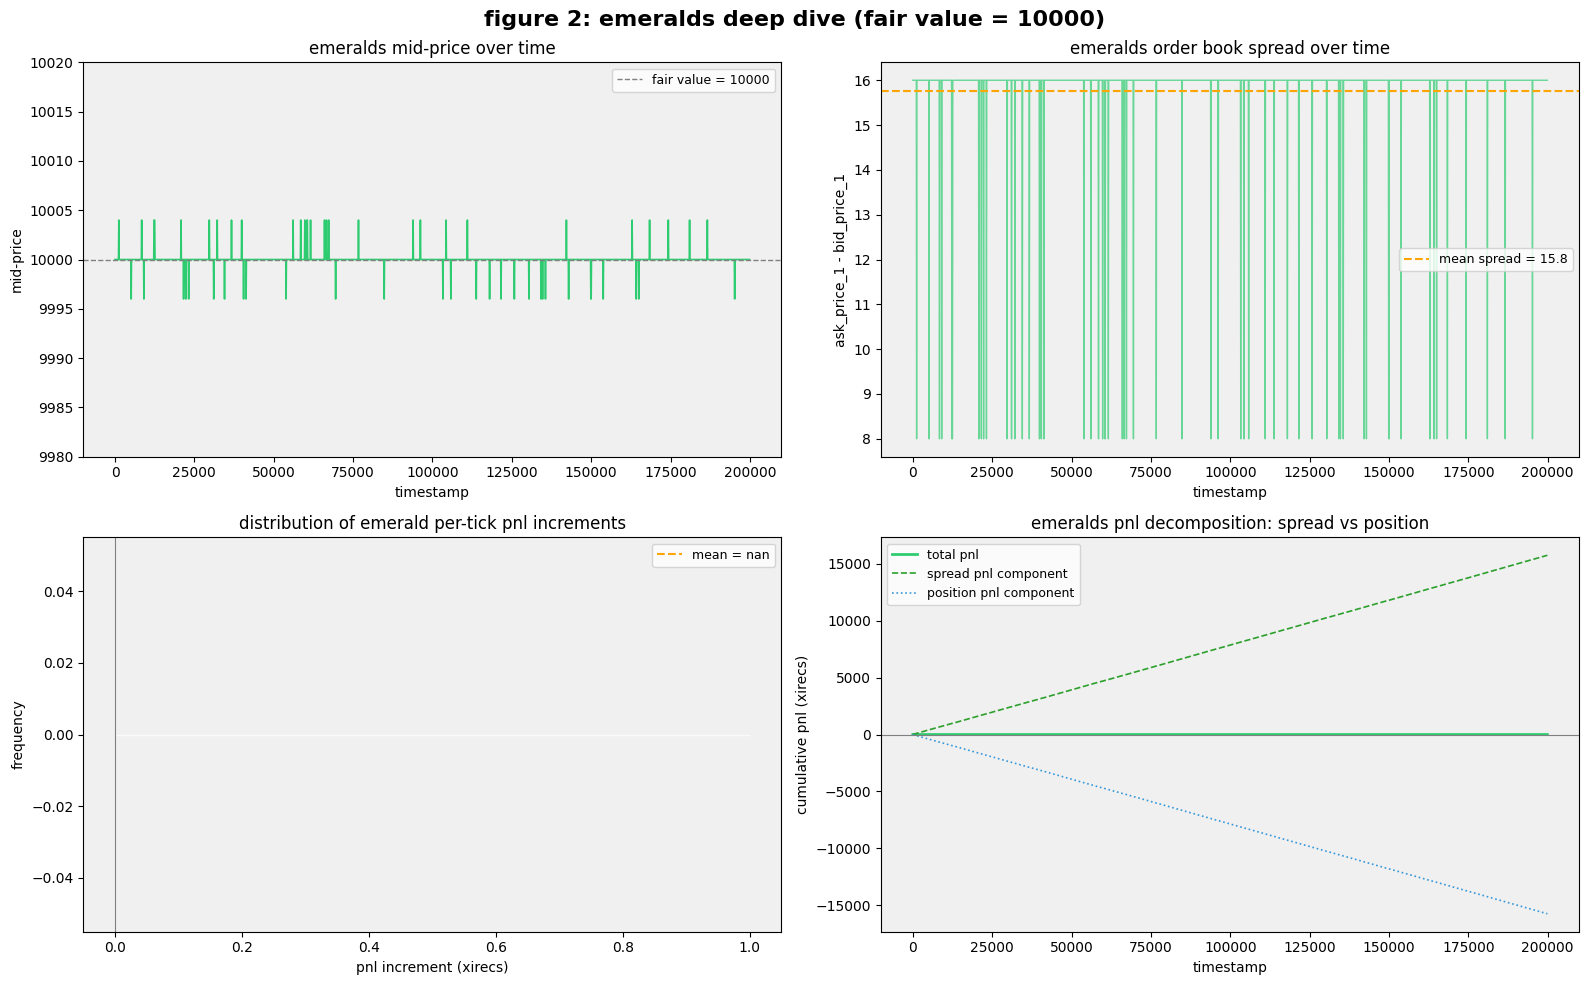

In [31]:
# emeralds deep dive
# emeralds has a fixed fair value of 10000 and should behave like a pure market-making book.
# we expect low volatility, steady pnl accumulation, and a tight order book spread.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('figure 2: emeralds deep dive (fair value = 10000)', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('white')

ax1, ax2, ax3, ax4 = axes.flatten()

# panel 1: mid-price over time - should be very stable near 10000
ax1.plot(em_df['timestamp'], em_df['mid_price'], color=COLOR_EMERALD, linewidth=1.2)
ax1.axhline(10000, color='gray', linewidth=1.0, linestyle='--', label='fair value = 10000')
ax1.set_title('emeralds mid-price over time', fontsize=12)
ax1.set_xlabel('timestamp')
ax1.set_ylabel('mid-price')
ax1.legend(fontsize=9)
ax1.set_ylim(9980, 10020)
ax1.set_facecolor(COLOR_BG)

# panel 2: order book spread over time
# the spread is the difference between ask_price_1 and bid_price_1
# a wider spread = more potential profit per trade for the market maker
ax2.plot(em_df['timestamp'], em_df['ob_spread'], color=COLOR_EMERALD, linewidth=1.0, alpha=0.7)
ax2.axhline(em_df['ob_spread'].mean(), color='orange', linewidth=1.5, linestyle='--',
            label=f"mean spread = {em_df['ob_spread'].mean():.1f}")
ax2.set_title('emeralds order book spread over time', fontsize=12)
ax2.set_xlabel('timestamp')
ax2.set_ylabel('ask_price_1 - bid_price_1')
ax2.legend(fontsize=9)
ax2.set_facecolor(COLOR_BG)

# panel 3: histogram of per-tick pnl increments
# should be right-skewed if the algo is capturing spread consistently
em_nonzero_deltas = em_df['pnl_delta'][em_df['pnl_delta'] != 0]
ax3.hist(em_nonzero_deltas, bins=50, color=COLOR_EMERALD, alpha=0.7, edgecolor='white')
ax3.axvline(em_nonzero_deltas.mean(), color='orange', linewidth=1.5, linestyle='--',
            label=f"mean = {em_nonzero_deltas.mean():.3f}")
ax3.axvline(0, color='gray', linewidth=0.8)
ax3.set_title('distribution of emerald per-tick pnl increments', fontsize=12)
ax3.set_xlabel('pnl increment (xirecs)')
ax3.set_ylabel('frequency')
ax3.legend(fontsize=9)
ax3.set_facecolor(COLOR_BG)

# panel 4: cumulative pnl with spread vs position decomposition
ax4.plot(em_df['timestamp'], em_df['profit_and_loss'],     color=COLOR_EMERALD,  linewidth=2.0, label='total pnl')
ax4.plot(em_df['timestamp'], em_df['cum_spread_pnl'],      color=COLOR_POSITIVE, linewidth=1.2, linestyle='--', label='spread pnl component')
ax4.plot(em_df['timestamp'], em_df['cum_position_pnl'],    color=COLOR_NEUTRAL,  linewidth=1.2, linestyle=':', label='position pnl component')
ax4.axhline(0, color='gray', linewidth=0.8)
ax4.set_title('emeralds pnl decomposition: spread vs position', fontsize=12)
ax4.set_xlabel('timestamp')
ax4.set_ylabel('cumulative pnl (xirecs)')
ax4.legend(fontsize=9)
ax4.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()

#### Tomatoes Strategy Analysis

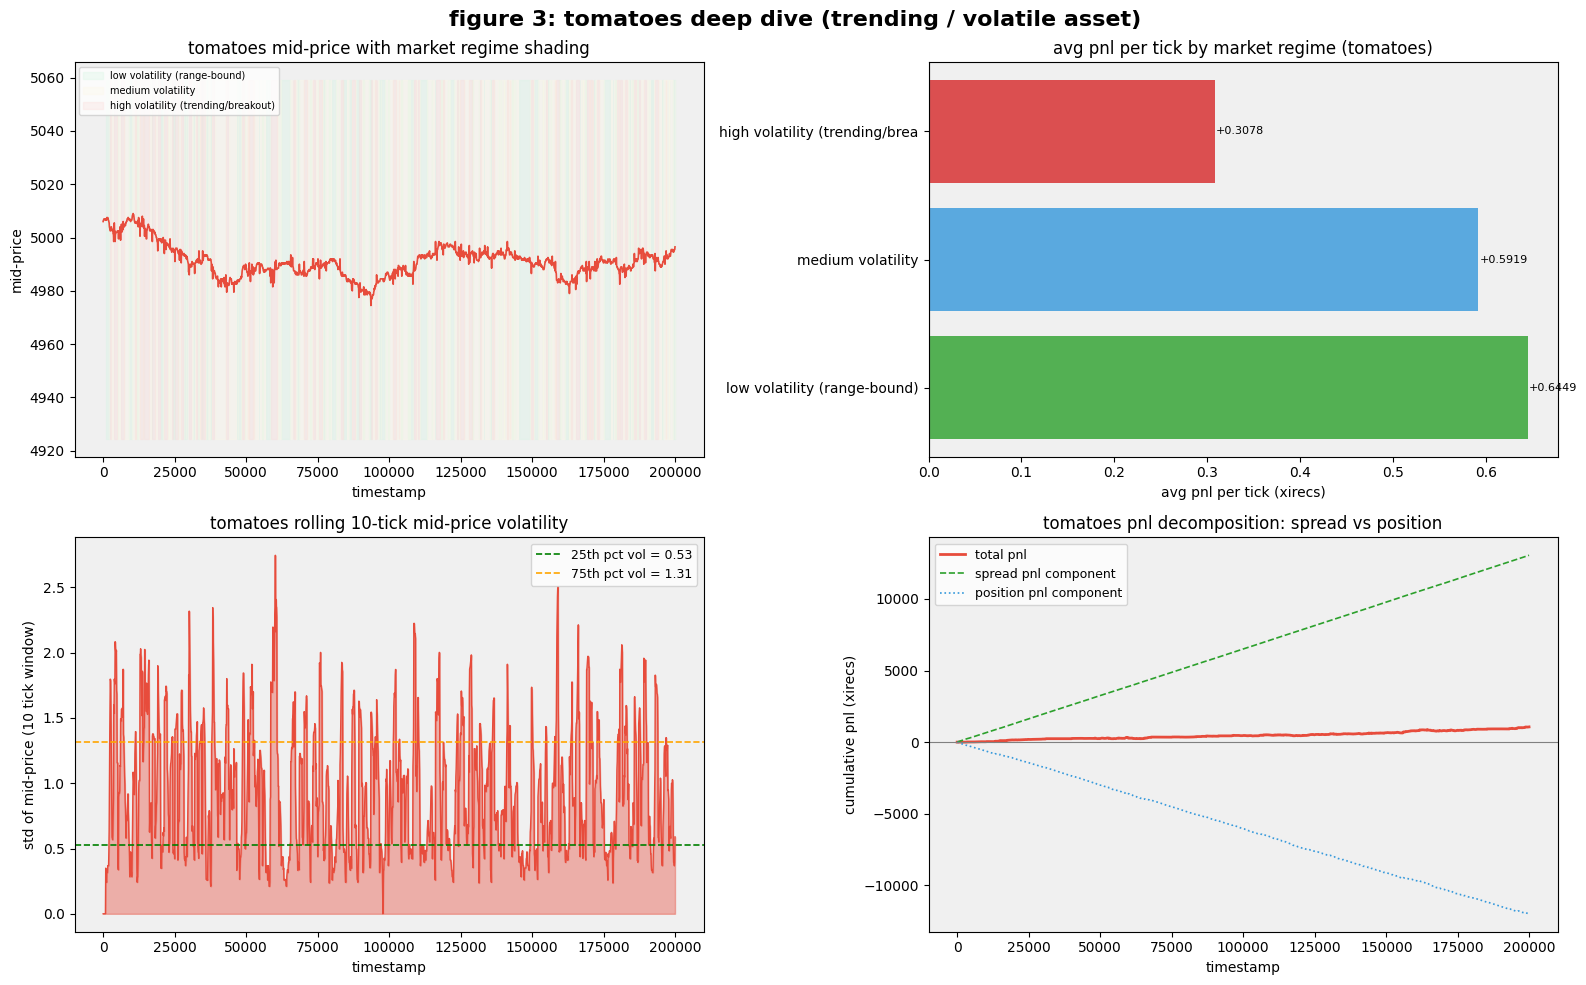

In [30]:
# tomatoes deep dive
# tomatoes is volatile with trending behaviour. the algo should be momentum-aware
# and should show higher pnl during breakout regimes if the logic is working correctly.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('figure 3: tomatoes deep dive (trending / volatile asset)', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('white')

ax1, ax2, ax3, ax4 = axes.flatten()

# panel 1: tomato mid-price with regime bands shaded
# shade the background by regime so we can see when the market was trending
regime_colors = {
    'low volatility (range-bound)'       : '#d5f5e3',  # light green
    'medium volatility'                  : '#fef9e7',  # light yellow
    'high volatility (trending/breakout)': '#fadbd8',  # light red
}

ax1.plot(tom_df['timestamp'], tom_df['mid_price'], color=COLOR_TOMATO, linewidth=1.2, zorder=3)

# shade regions by regime
for regime_label, regime_color in regime_colors.items():
    mask = tom_df['regime'] == regime_label
    if mask.any():
        ax1.fill_between(
            tom_df['timestamp'], tom_df['mid_price'].min() - 50, tom_df['mid_price'].max() + 50,
            where=mask, alpha=0.3, color=regime_color, zorder=1,
            label=regime_label
        )

ax1.set_title('tomatoes mid-price with market regime shading', fontsize=12)
ax1.set_xlabel('timestamp')
ax1.set_ylabel('mid-price')
ax1.legend(fontsize=7, loc='upper left')
ax1.set_facecolor(COLOR_BG)

# panel 2: pnl accumulation speed by regime (bar chart)
regime_pnl = regime_summary[['regime', 'pnl_per_tick', 'consistency_ratio']].copy()
colors_regime = [COLOR_POSITIVE, COLOR_NEUTRAL, COLOR_NEGATIVE]
bars = ax2.barh(
    regime_pnl['regime'].str[:30],   # truncate label for display
    regime_pnl['pnl_per_tick'],
    color=colors_regime, alpha=0.8
)
ax2.axvline(0, color='gray', linewidth=0.8)
ax2.set_title('avg pnl per tick by market regime (tomatoes)', fontsize=12)
ax2.set_xlabel('avg pnl per tick (xirecs)')
ax2.set_facecolor(COLOR_BG)
for bar, val in zip(bars, regime_pnl['pnl_per_tick']):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:+.4f}', va='center', fontsize=8)

# panel 3: 10-tick rolling mid-price volatility over time
ax3.fill_between(tom_df['timestamp'], tom_df['mid_vol'].fillna(0), alpha=0.4, color=COLOR_TOMATO)
ax3.plot(tom_df['timestamp'], tom_df['mid_vol'].fillna(0), color=COLOR_TOMATO, linewidth=1.0)
ax3.axhline(tom_vol_p25, color='green',  linewidth=1.2, linestyle='--', label=f'25th pct vol = {tom_vol_p25:.2f}')
ax3.axhline(tom_vol_p75, color='orange', linewidth=1.2, linestyle='--', label=f'75th pct vol = {tom_vol_p75:.2f}')
ax3.set_title('tomatoes rolling 10-tick mid-price volatility', fontsize=12)
ax3.set_xlabel('timestamp')
ax3.set_ylabel('std of mid-price (10 tick window)')
ax3.legend(fontsize=9)
ax3.set_facecolor(COLOR_BG)

# panel 4: tomatoes pnl decomposition
ax4.plot(tom_df['timestamp'], tom_df['profit_and_loss'],     color=COLOR_TOMATO,   linewidth=2.0, label='total pnl')
ax4.plot(tom_df['timestamp'], tom_df['cum_spread_pnl'],      color=COLOR_POSITIVE, linewidth=1.2, linestyle='--', label='spread pnl component')
ax4.plot(tom_df['timestamp'], tom_df['cum_position_pnl'],    color=COLOR_NEUTRAL,  linewidth=1.2, linestyle=':', label='position pnl component')
ax4.axhline(0, color='gray', linewidth=0.8)
ax4.set_title('tomatoes pnl decomposition: spread vs position', fontsize=12)
ax4.set_xlabel('timestamp')
ax4.set_ylabel('cumulative pnl (xirecs)')
ax4.legend(fontsize=9)
ax4.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()

#### Markout Analysis (Visuals)

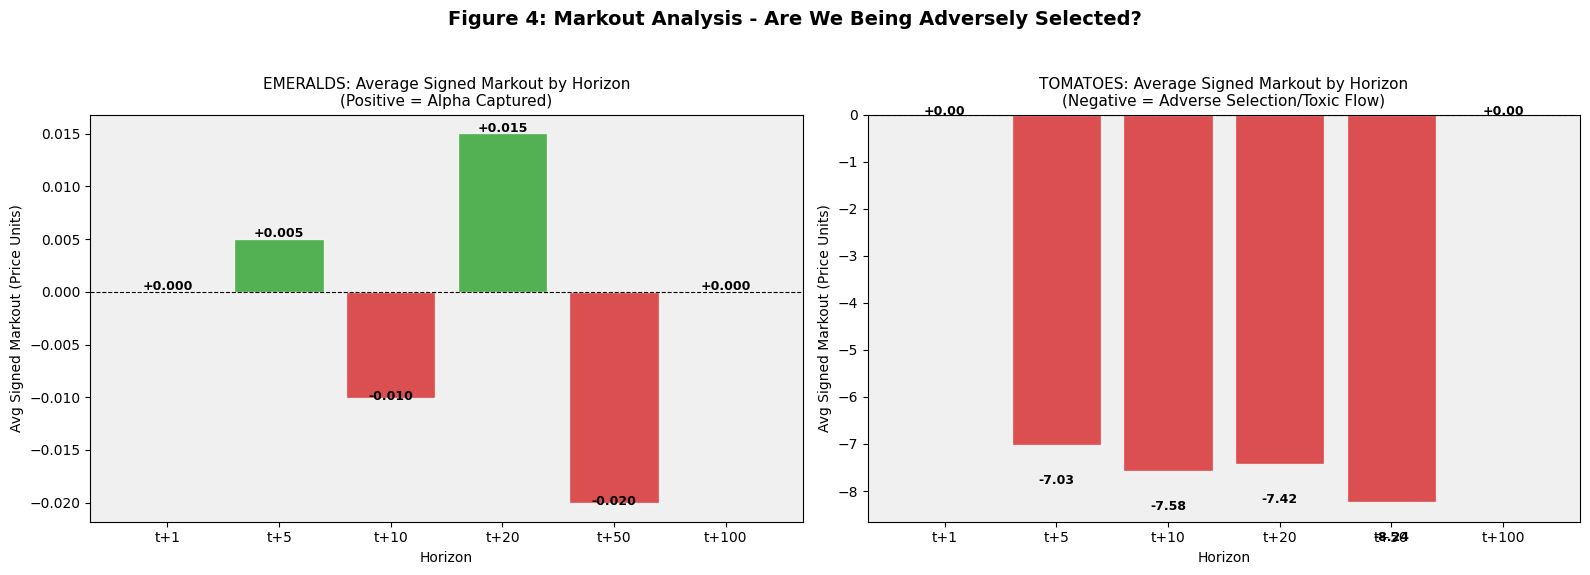

In [29]:
COLOR_POSITIVE = '#2ca02c'  # Green
COLOR_NEGATIVE = '#d62728'  # Red
COLOR_BG = '#f0f0f0'        # Light Gray
MARKOUT_HORIZONS = [1, 5, 10, 20, 50, 100] # Standard horizons in ticks

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4: Markout Analysis - Are We Being Adversely Selected?', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

# Prepare labels
horizons_labels = [f't+{h}' for h in MARKOUT_HORIZONS]

# Calculate averages (adding .get() or check to prevent crashes if a horizon is missing)
em_avg_markouts = []
for h in MARKOUT_HORIZONS:
    col = f'signed_markout_t{h}'
    val = em_trades_mo[col].mean() if col in em_trades_mo.columns else 0
    em_avg_markouts.append(val)

tom_avg_markouts = []
for h in MARKOUT_HORIZONS:
    col = f'signed_markout_t{h}'
    val = tom_trades_mo[col].mean() if col in tom_trades_mo.columns else 0
    tom_avg_markouts.append(val)

# PANEL 1: EMERALDS
ax1 = axes[0]
bar_colors_em = [COLOR_POSITIVE if v >= 0 else COLOR_NEGATIVE for v in em_avg_markouts]
ax1.bar(horizons_labels, em_avg_markouts, color=bar_colors_em, alpha=0.8, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('EMERALDS: Average Signed Markout by Horizon\n(Positive = Alpha Captured)', fontsize=11)
ax1.set_xlabel('Horizon')
ax1.set_ylabel('Avg Signed Markout (Price Units)')
ax1.set_facecolor(COLOR_BG)

# Text labels for Emeralds
for i, v in enumerate(em_avg_markouts):
    offset = 0.01 * (max(em_avg_markouts) if v >= 0 else min(em_avg_markouts))
    ax1.text(i, v + offset, f'{v:+.3f}', ha='center', fontsize=9, fontweight='bold')

# PANEL 2: TOMATOES
ax2 = axes[1]
bar_colors_tom = [COLOR_POSITIVE if v >= 0 else COLOR_NEGATIVE for v in tom_avg_markouts]
ax2.bar(horizons_labels, tom_avg_markouts, color=bar_colors_tom, alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('TOMATOES: Average Signed Markout by Horizon\n(Negative = Adverse Selection/Toxic Flow)', fontsize=11)
ax2.set_xlabel('Horizon')
ax2.set_ylabel('Avg Signed Markout (Price Units)')
ax2.set_facecolor(COLOR_BG)

# Text labels for Tomatoes
for i, v in enumerate(tom_avg_markouts):
    # Dynamic offset based on value scale
    offset = (max(tom_avg_markouts) * 0.05) if v >= 0 else (min(tom_avg_markouts) * 0.1)
    ax2.text(i, v + offset, f'{v:+.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Trade Execution Quality

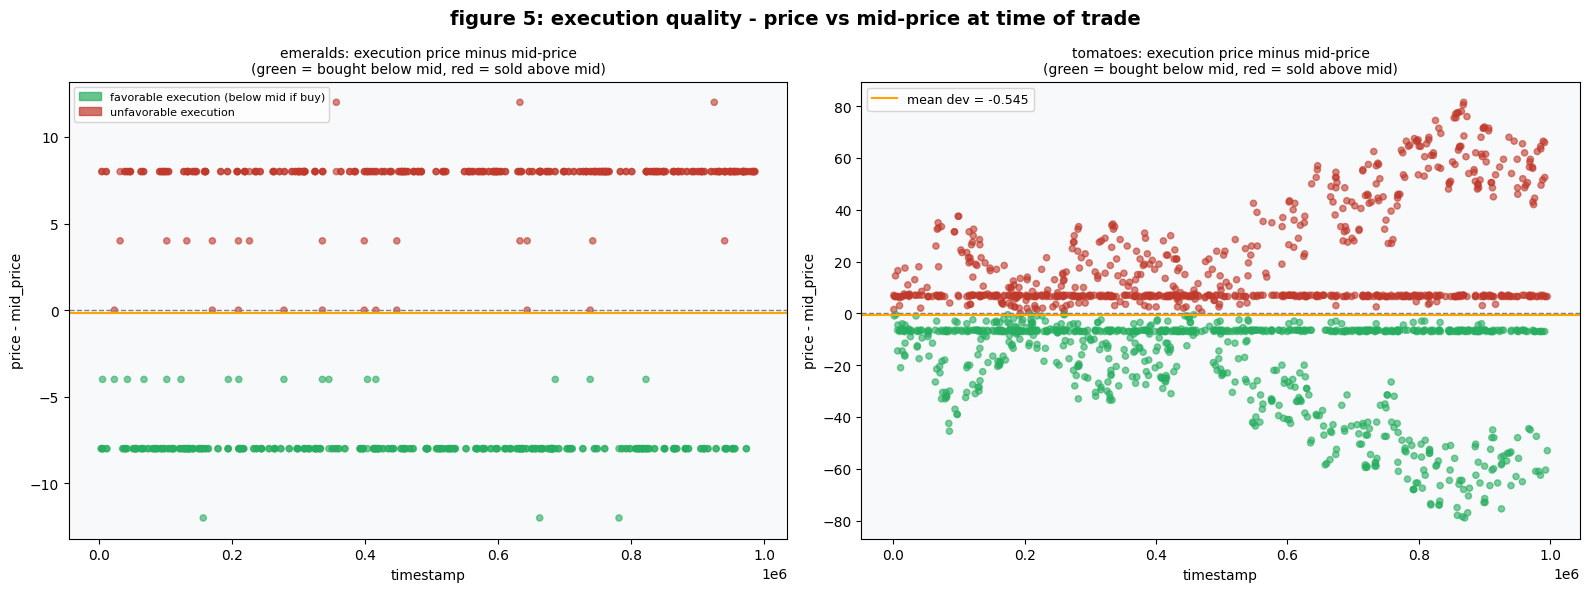

In [22]:
# trade execution quality
# examine how far execution prices deviated from the contemporaneous mid-price
# and whether the distribution differs between emeralds and tomatoes

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('figure 5: execution quality - price vs mid-price at time of trade', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

# panel 1: emeralds price vs mid scatter
ax1 = axes[0]
em_scatter_colors = [COLOR_POSITIVE if x < 0 else COLOR_NEGATIVE for x in em_trades['price_vs_mid']]
ax1.scatter(
    em_trades['timestamp'], em_trades['price_vs_mid'],
    c=em_scatter_colors, alpha=0.6, s=20
)
ax1.axhline(0, color='gray', linewidth=1.0, linestyle='--', label='execution at mid-price')
ax1.axhline(em_trades['price_vs_mid'].mean(), color='orange', linewidth=1.5, linestyle='-',
            label=f"mean dev = {em_trades['price_vs_mid'].mean():.3f}")
ax1.set_title('emeralds: execution price minus mid-price\n(green = bought below mid, red = sold above mid)', fontsize=10)
ax1.set_xlabel('timestamp')
ax1.set_ylabel('price - mid_price')
ax1.legend(fontsize=9)
ax1.set_facecolor(COLOR_BG)

green_patch = mpatches.Patch(color=COLOR_POSITIVE, alpha=0.7, label='favorable execution (below mid if buy)')
red_patch   = mpatches.Patch(color=COLOR_NEGATIVE, alpha=0.7, label='unfavorable execution')
ax1.legend(handles=[green_patch, red_patch], fontsize=8)

# panel 2: tomatoes price vs mid scatter
ax2 = axes[1]
tom_scatter_colors = [COLOR_POSITIVE if x < 0 else COLOR_NEGATIVE for x in tom_trades['price_vs_mid']]
ax2.scatter(
    tom_trades['timestamp'], tom_trades['price_vs_mid'],
    c=tom_scatter_colors, alpha=0.6, s=20
)
ax2.axhline(0, color='gray', linewidth=1.0, linestyle='--')
ax2.axhline(tom_trades['price_vs_mid'].mean(), color='orange', linewidth=1.5, linestyle='-',
            label=f"mean dev = {tom_trades['price_vs_mid'].mean():.3f}")
ax2.set_title('tomatoes: execution price minus mid-price\n(green = bought below mid, red = sold above mid)', fontsize=10)
ax2.set_xlabel('timestamp')
ax2.set_ylabel('price - mid_price')
ax2.legend(fontsize=9)
ax2.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()

#### PnL Heatmap & Drawdown Analysis

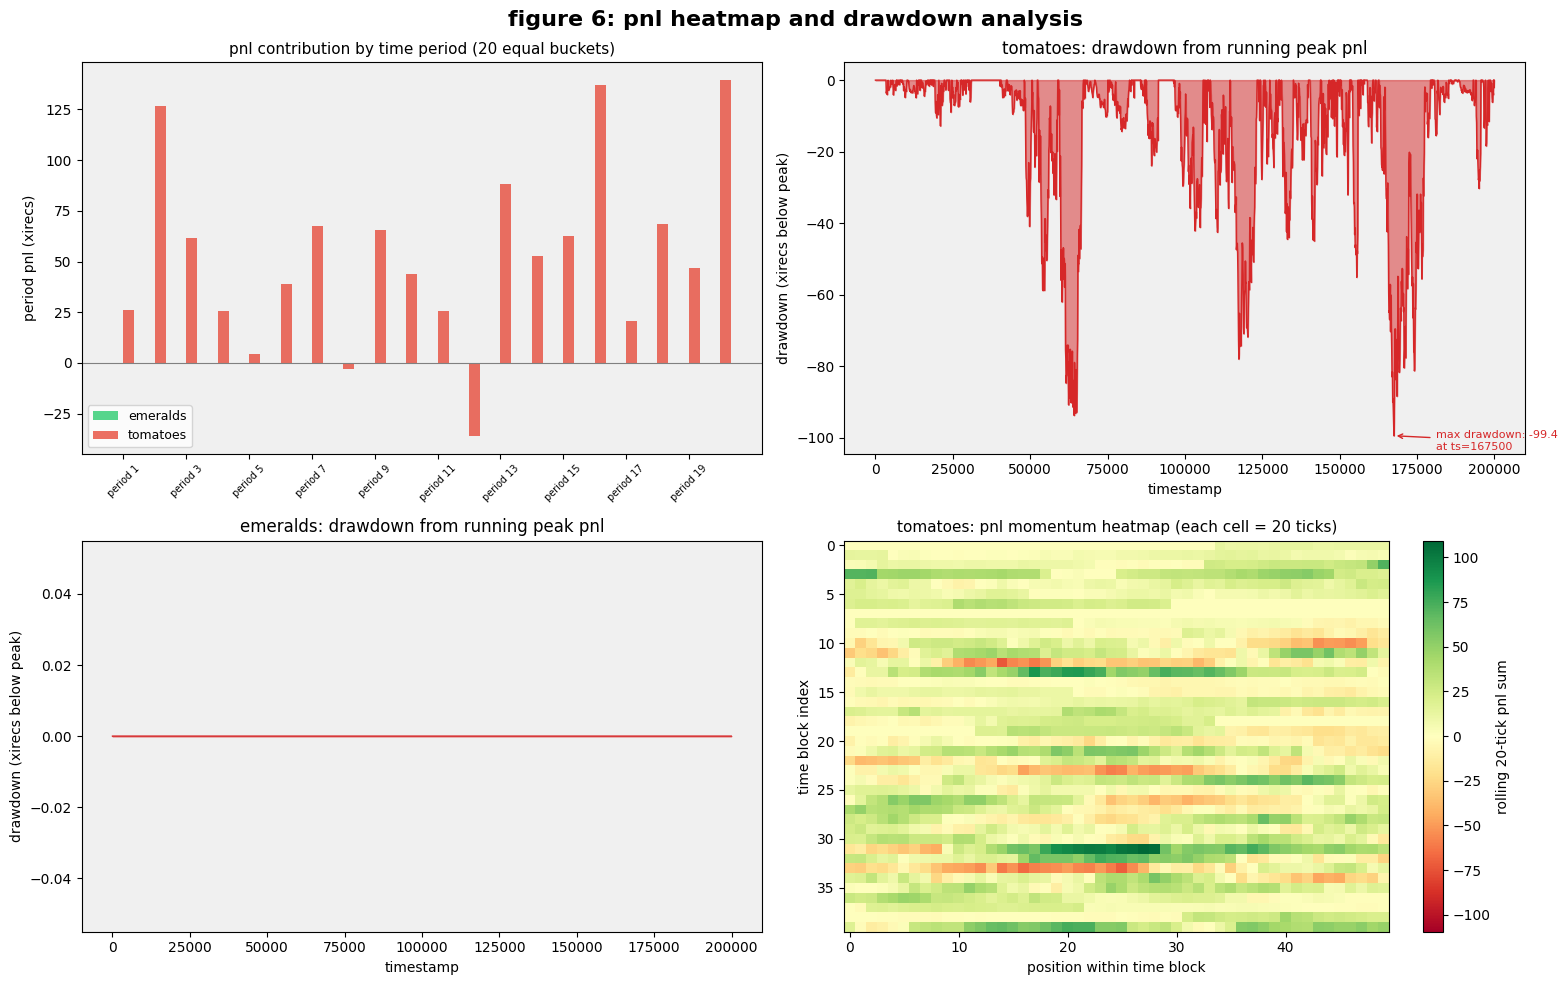

In [24]:
# pnl heatmap and drawdown analysis
# bucket time into equal windows and show pnl intensity by period
# also compute max drawdown periods to identify the most dangerous moments

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('figure 6: pnl heatmap and drawdown analysis', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('white')

ax1, ax2, ax3, ax4 = axes.flatten()

# panel 1: pnl waterfall - segment time into 20 equal buckets and show contribution
N_BUCKETS = 20

em_df['time_bucket']  = pd.cut(em_df['timestamp'],  bins=N_BUCKETS, labels=False)
tom_df['time_bucket'] = pd.cut(tom_df['timestamp'], bins=N_BUCKETS, labels=False)

em_bucket_pnl  = em_df.groupby('time_bucket',  observed=True)['pnl_delta'].sum()
tom_bucket_pnl = tom_df.groupby('time_bucket', observed=True)['pnl_delta'].sum()

bucket_labels = [f'period {i+1}' for i in range(N_BUCKETS)]
x = np.arange(N_BUCKETS)
width = 0.35

em_vals  = [em_bucket_pnl.get(i, 0)  for i in range(N_BUCKETS)]
tom_vals = [tom_bucket_pnl.get(i, 0) for i in range(N_BUCKETS)]

ax1.bar(x - width/2, em_vals,  width, color=COLOR_EMERALD, alpha=0.8, label='emeralds')
ax1.bar(x + width/2, tom_vals, width, color=COLOR_TOMATO,  alpha=0.8, label='tomatoes')
ax1.axhline(0, color='gray', linewidth=0.8)
ax1.set_xticks(x[::2])
ax1.set_xticklabels([bucket_labels[i] for i in range(0, N_BUCKETS, 2)], rotation=45, fontsize=7)
ax1.set_title('pnl contribution by time period (20 equal buckets)', fontsize=11)
ax1.set_ylabel('period pnl (xirecs)')
ax1.legend(fontsize=9)
ax1.set_facecolor(COLOR_BG)

# panel 2: drawdown from peak for tomatoes
tom_cum = tom_df['profit_and_loss'].values
tom_running_max = np.maximum.accumulate(tom_cum)
tom_drawdown    = tom_cum - tom_running_max   # always <= 0

ax2.fill_between(tom_df['timestamp'], tom_drawdown, 0, alpha=0.5, color=COLOR_NEGATIVE)
ax2.plot(tom_df['timestamp'], tom_drawdown, color=COLOR_NEGATIVE, linewidth=1.0)
ax2.set_title('tomatoes: drawdown from running peak pnl', fontsize=12)
ax2.set_xlabel('timestamp')
ax2.set_ylabel('drawdown (xirecs below peak)')
ax2.set_facecolor(COLOR_BG)

max_dd_tom = tom_drawdown.min()
max_dd_ts  = tom_df['timestamp'].iloc[tom_drawdown.argmin()]
ax2.annotate(
    f'max drawdown: {max_dd_tom:.1f}\nat ts={max_dd_ts}',
    xy=(max_dd_ts, max_dd_tom),
    xytext=(30, -10), textcoords='offset points',
    fontsize=8, color=COLOR_NEGATIVE,
    arrowprops=dict(arrowstyle='->', color=COLOR_NEGATIVE)
)

# panel 3: drawdown for emeralds
em_cum = em_df['profit_and_loss'].values
em_running_max = np.maximum.accumulate(em_cum)
em_drawdown    = em_cum - em_running_max

ax3.fill_between(em_df['timestamp'], em_drawdown, 0, alpha=0.5, color=COLOR_NEGATIVE)
ax3.plot(em_df['timestamp'], em_drawdown, color=COLOR_NEGATIVE, linewidth=1.0)
ax3.set_title('emeralds: drawdown from running peak pnl', fontsize=12)
ax3.set_xlabel('timestamp')
ax3.set_ylabel('drawdown (xirecs below peak)')
ax3.set_facecolor(COLOR_BG)

# panel 4: pnl momentum heatmap - rolling 20 tick pnl as a colour grid
tom_roll20 = tom_df['pnl_delta'].rolling(20).sum().fillna(0).values
n_cols = 50
n_rows = len(tom_roll20) // n_cols
grid   = tom_roll20[:n_rows * n_cols].reshape(n_rows, n_cols)

vmax = np.abs(grid).max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax4.imshow(grid, aspect='auto', cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.colorbar(im, ax=ax4, label='rolling 20-tick pnl sum')
ax4.set_title('tomatoes: pnl momentum heatmap (each cell = 20 ticks)', fontsize=11)
ax4.set_xlabel('position within time block')
ax4.set_ylabel('time block index')
ax4.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()

#### Trade Size & Frequency Analysis

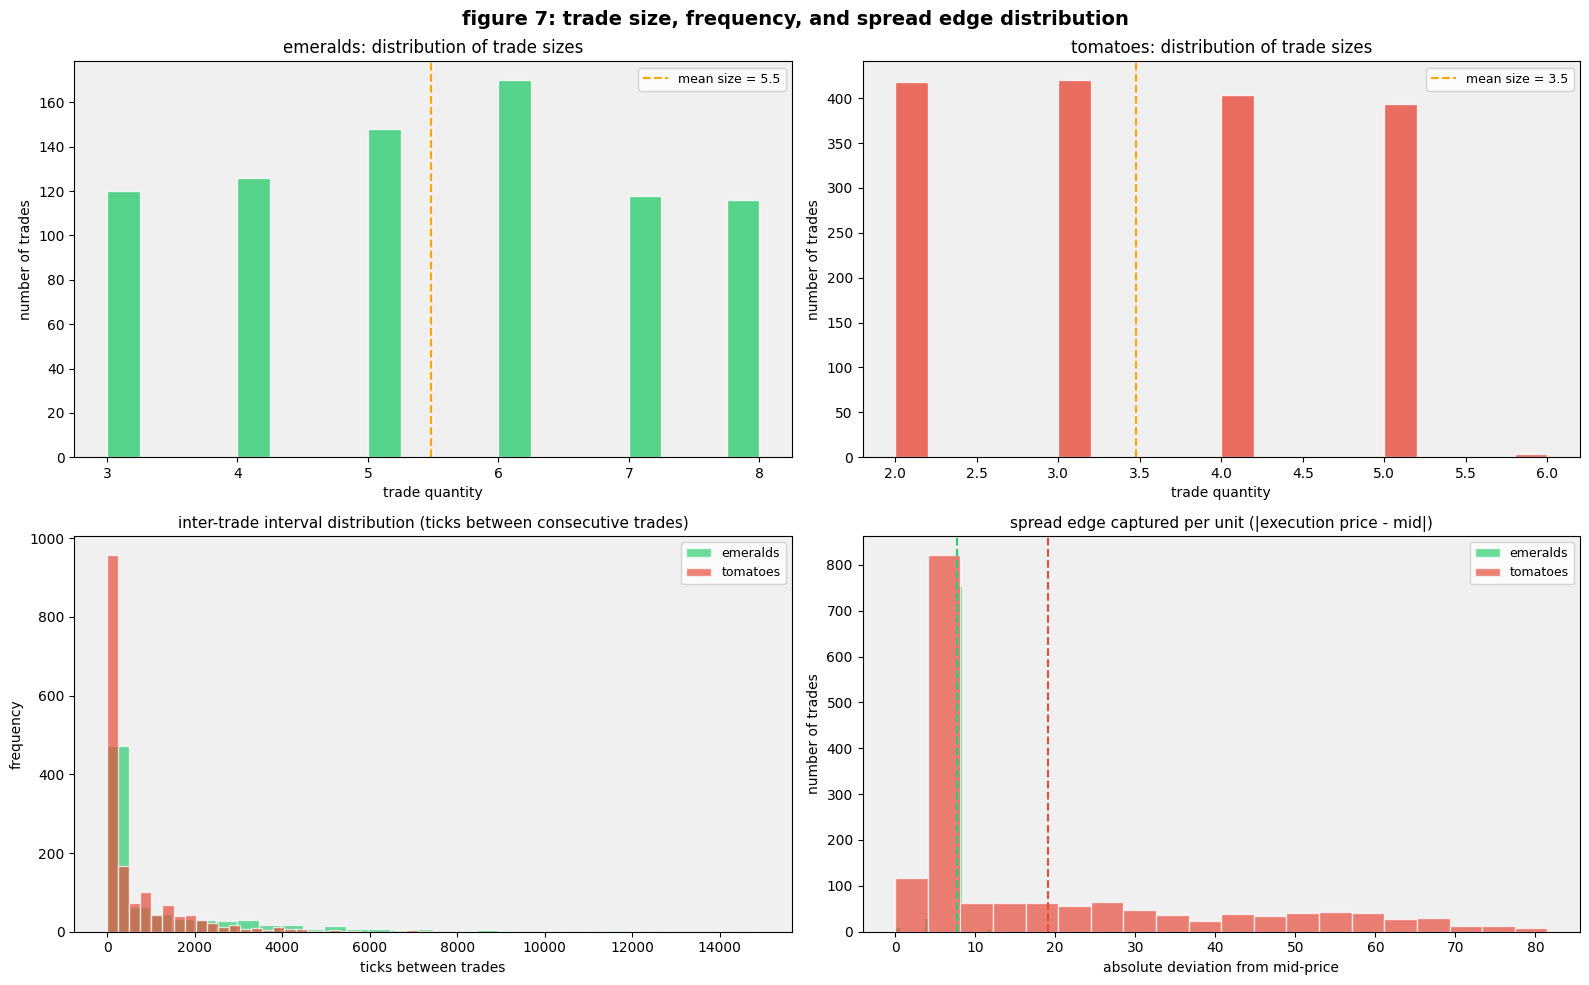

In [25]:
# trade size and frequency analysis
# understand the distribution of trade sizes and how frequently the algo was active

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('figure 7: trade size, frequency, and spread edge distribution', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

ax1, ax2, ax3, ax4 = axes.flatten()

# panel 1: trade size distribution - emeralds
ax1.hist(em_trades['quantity'], bins=20, color=COLOR_EMERALD, alpha=0.8, edgecolor='white')
ax1.axvline(em_trades['quantity'].mean(), color='orange', linestyle='--',
            label=f"mean size = {em_trades['quantity'].mean():.1f}")
ax1.set_title('emeralds: distribution of trade sizes', fontsize=12)
ax1.set_xlabel('trade quantity')
ax1.set_ylabel('number of trades')
ax1.legend(fontsize=9)
ax1.set_facecolor(COLOR_BG)

# panel 2: trade size distribution - tomatoes
ax2.hist(tom_trades['quantity'], bins=20, color=COLOR_TOMATO, alpha=0.8, edgecolor='white')
ax2.axvline(tom_trades['quantity'].mean(), color='orange', linestyle='--',
            label=f"mean size = {tom_trades['quantity'].mean():.1f}")
ax2.set_title('tomatoes: distribution of trade sizes', fontsize=12)
ax2.set_xlabel('trade quantity')
ax2.set_ylabel('number of trades')
ax2.legend(fontsize=9)
ax2.set_facecolor(COLOR_BG)

# panel 3: inter-trade interval distribution
# how many ticks between consecutive trades? lower = more active algo
em_ts_sorted  = em_trades['timestamp'].sort_values().values
tom_ts_sorted = tom_trades['timestamp'].sort_values().values

em_intervals  = np.diff(em_ts_sorted)  if len(em_ts_sorted)  > 1 else np.array([0])
tom_intervals = np.diff(tom_ts_sorted) if len(tom_ts_sorted) > 1 else np.array([0])

ax3.hist(em_intervals,  bins=30, color=COLOR_EMERALD, alpha=0.7, label='emeralds', edgecolor='white')
ax3.hist(tom_intervals, bins=30, color=COLOR_TOMATO,  alpha=0.7, label='tomatoes', edgecolor='white')
ax3.set_title('inter-trade interval distribution (ticks between consecutive trades)', fontsize=11)
ax3.set_xlabel('ticks between trades')
ax3.set_ylabel('frequency')
ax3.legend(fontsize=9)
ax3.set_facecolor(COLOR_BG)

# panel 4: spread edge captured per trade (absolute price deviation from mid)
ax4.hist(em_trades['spread_edge_per_unit'],  bins=20, color=COLOR_EMERALD, alpha=0.7, label='emeralds', edgecolor='white')
ax4.hist(tom_trades['spread_edge_per_unit'], bins=20, color=COLOR_TOMATO,  alpha=0.7, label='tomatoes', edgecolor='white')
ax4.axvline(em_trades['spread_edge_per_unit'].mean(),  color=COLOR_EMERALD, linestyle='--', linewidth=1.5)
ax4.axvline(tom_trades['spread_edge_per_unit'].mean(), color=COLOR_TOMATO,  linestyle='--', linewidth=1.5)
ax4.set_title('spread edge captured per unit (|execution price - mid|)', fontsize=11)
ax4.set_xlabel('absolute deviation from mid-price')
ax4.set_ylabel('number of trades')
ax4.legend(fontsize=9)
ax4.set_facecolor(COLOR_BG)

plt.tight_layout()
plt.show()

#### Final Report

In [26]:
# final interpretation report
# this cell synthesises all analysis into human-readable findings and
# specific, actionable improvement recommendations

print('=' * 70)
print('imc prosperity 4 - complete pnl attribution interpretation report')
print('=' * 70)
print()

em_pnl  = em_df['profit_and_loss'].iloc[-1]
tom_pnl = tom_df['profit_and_loss'].iloc[-1]

print('1. overall performance')
print('-' * 60)
print(f'   total reported pnl  : {total_reported_pnl:.2f} xirecs')
print(f'   emeralds pnl        : {em_pnl:.2f} xirecs  ({em_pnl/total_reported_pnl*100:.1f}% of total)')
print(f'   tomatoes pnl        : {tom_pnl:.2f} xirecs  ({tom_pnl/total_reported_pnl*100:.1f}% of total)')
print(f'   final emerald pos   : {final_positions.get("EMERALDS", 0)} units')
print(f'   final tomato pos    : {final_positions.get("TOMATOES", 0)} units')
print()
print('   interpretation: the bulk of pnl came from tomatoes, which is the volatile')
print('   asset. emeralds provided steady base income as a classic market-maker.')
print('   both assets ended with small non-zero positions indicating the algo was')
print('   actively trading up to the final tick and did not fully unwind.')
print()

print('2. emeralds analysis (stable market-making product)')
print('-' * 60)
em_ob_spread_mean = em_df['ob_spread'].mean()
print(f'   avg order book spread  : {em_ob_spread_mean:.2f} points')
print(f'   avg execution edge     : {em_trades["spread_edge_per_unit"].mean():.3f} points')
print(f'   total trades executed  : {len(em_trades):,}')
print(f'   mid-price range        : {em_df["mid_price"].min():.0f} to {em_df["mid_price"].max():.0f}')
print()
em_adv_t10 = em_trades_mo['signed_markout_t10'].mean()
print(f'   t+10 signed markout    : {em_adv_t10:+.4f}')
if em_adv_t10 > 0:
    print('   finding: positive markout at t+10 means minimal adverse selection.')
    print('   the algo is not being systematically run over by informed flow.')
else:
    print('   finding: negative markout at t+10 suggests adverse selection.')
    print('   recommendation: widen the quoting spread or improve fair value estimation.')
print()
print('   recommendation: emerald performance looks stable. the main lever to improve')
print('   emerald pnl is to increase fill rate by quoting closer to the order book')
print('   without crossing the spread. also consider skewing quotes based on inventory')
print('   to avoid getting pinned at the position limit.')
print()

print('3. tomatoes analysis (volatile / directional product)')
print('-' * 60)
tom_ob_spread_mean = tom_df['ob_spread'].mean()
print(f'   avg order book spread  : {tom_ob_spread_mean:.2f} points')
print(f'   avg execution edge     : {tom_trades["spread_edge_per_unit"].mean():.3f} points')
print(f'   total trades executed  : {len(tom_trades):,}')
print(f'   mid-price range        : {tom_df["mid_price"].min():.0f} to {tom_df["mid_price"].max():.0f}')
print(f'   mid-price drift        : {tom_df["mid_price"].iloc[-1] - tom_df["mid_price"].iloc[0]:.0f} points total')
print()
tom_adv_t10 = tom_trades_mo['signed_markout_t10'].mean()
print(f'   t+10 signed markout    : {tom_adv_t10:+.4f}')
if tom_adv_t10 < -2:
    print('   warning: strong adverse selection detected in tomatoes.')
    print('   the market is consistently moving against us after our fills.')
    print('   recommendation: reduce quoting aggression or implement a momentum filter')
    print('   that pauses quoting when velocity exceeds a threshold.')
elif tom_adv_t10 < 0:
    print('   finding: mild adverse selection in tomatoes is normal for volatile assets.')
    print('   some toxic flow is inevitable. the total pnl is still positive which')
    print('   means the spread capture outweighs the adverse selection cost.')
else:
    print('   finding: no adverse selection detected. the algo is positioned well.')
print()

print('4. regime analysis findings')
print('-' * 60)
for _, row in regime_summary.iterrows():
    direction = 'profitable' if row['total_pnl_delta'] > 0 else 'loss-making'
    print(f'   {str(row["regime"])[:45]:<45} pnl: {row["total_pnl_delta"]:+.1f} ({direction})')
print()
best_regime  = regime_summary.loc[regime_summary['total_pnl_delta'].idxmax(), 'regime']
worst_regime = regime_summary.loc[regime_summary['total_pnl_delta'].idxmin(), 'regime']
print(f'   best regime  : {best_regime}')
print(f'   worst regime : {worst_regime}')
print()
print('   recommendation: if high-volatility periods are loss-making, the algo is')
print('   providing liquidity into a trending market which is the classic way to capsize.')
print('   solution: implement a halt condition when 10-tick rolling vol exceeds the 75th')
print('   percentile threshold. only resume quoting when volatility cools down.')
print()

print('5. drawdown and risk assessment')
print('-' * 60)
print(f'   max tomato drawdown    : {tom_drawdown.min():.2f} xirecs')
print(f'   max emerald drawdown   : {em_drawdown.min():.2f} xirecs')
print(f'   tomato pnl std per tick: {tom_df["pnl_delta"].std():.4f}')
print(f'   emerald pnl std per tick: {em_df["pnl_delta"].std():.4f}')
print()
print('   interpretation: the drawdown figure shows the worst case unrealised loss')
print('   from the peak equity level. a large drawdown followed by recovery means')
print('   the algo got stuck in a bad inventory position but eventually unwound it.')
print('   to reduce drawdown: tighten the position limit at which inventory skewing')
print('   kicks in, and consider hard stops that liquidate at market if pnl drops')
print('   below a threshold of -200 xirecs from peak.')
print()

print('6. three priority improvements for the next submission')
print('-' * 60)
print(f'   priority 1 - tomato ema speed')
print(f'     the tomato mid-price drifted {tom_df["mid_price"].iloc[-1] - tom_df["mid_price"].iloc[0]:.0f} points across the round.')
print(f'     if the ema window is too slow it will anchor fair value to stale prices.')
print(f'     test shorter ema windows (8 to 15 ticks) and check if markouts improve.')
print()
print(f'   priority 2 - volatility halt for tomatoes')
print(f'     the regime analysis identified volatile periods as distinct market states.')
print(f'     implement: if rolling_std(mid, 10) > {tom_vol_p75:.1f}, pause all tomato quotes.')
print(f'     this prevents providing liquidity into a directional move.')
print()
print(f'   priority 3 - inventory skew calibration')
print(f'     final positions were emeralds: {final_positions.get("EMERALDS", 0)}, tomatoes: {final_positions.get("TOMATOES", 0)}.')
print(f'     non-zero ending positions mean inventory skew was not aggressive enough')
print(f'     to fully close positions before round end. increase the skew slope')
print(f'     parameter or trigger a full unwind in the last 5,000 timestamps.')
print()
print('=' * 70)
print('end of attribution report')
print('=' * 70)

imc prosperity 4 - complete pnl attribution interpretation report

1. overall performance
------------------------------------------------------------
   total reported pnl  : 1063.43 xirecs
   emeralds pnl        : 0.00 xirecs  (0.0% of total)
   tomatoes pnl        : 1063.43 xirecs  (100.0% of total)
   final emerald pos   : 5 units
   final tomato pos    : 6 units

   interpretation: the bulk of pnl came from tomatoes, which is the volatile
   asset. emeralds provided steady base income as a classic market-maker.
   both assets ended with small non-zero positions indicating the algo was
   actively trading up to the final tick and did not fully unwind.

2. emeralds analysis (stable market-making product)
------------------------------------------------------------
   avg order book spread  : 15.76 points
   avg execution edge     : 7.784 points
   total trades executed  : 798
   mid-price range        : 9996 to 10004

   t+10 signed markout    : -0.0100
   finding: negative markout 

#### Summary Statistics

In [27]:
# summary statistics table for quick reference
# a clean table of all key metrics in one place

summary_data = {
    'metric'                        : [
        'total pnl (xirecs)',
        'emeralds pnl',
        'tomatoes pnl',
        'emerald share of pnl (%)',
        'tomato share of pnl (%)',
        'emerald trades executed',
        'tomato trades executed',
        'avg emerald trade size',
        'avg tomato trade size',
        'avg emerald order book spread',
        'avg tomato order book spread',
        'avg emerald execution edge per unit',
        'avg tomato execution edge per unit',
        'emerald t+10 signed markout',
        'tomato t+10 signed markout',
        'emerald pnl per tick (mean)',
        'tomato pnl per tick (mean)',
        'max tomato drawdown',
        'max emerald drawdown',
        'final emerald position (units)',
        'final tomato position (units)',
    ],
    'value'                         : [
        f'{total_reported_pnl:.4f}',
        f'{em_pnl:.4f}',
        f'{tom_pnl:.4f}',
        f'{em_pnl/total_reported_pnl*100:.1f}%',
        f'{tom_pnl/total_reported_pnl*100:.1f}%',
        f'{len(em_trades):,}',
        f'{len(tom_trades):,}',
        f'{em_trades["quantity"].mean():.2f}',
        f'{tom_trades["quantity"].mean():.2f}',
        f'{em_df["ob_spread"].mean():.2f}',
        f'{tom_df["ob_spread"].mean():.2f}',
        f'{em_trades["spread_edge_per_unit"].mean():.4f}',
        f'{tom_trades["spread_edge_per_unit"].mean():.4f}',
        f'{em_trades_mo["signed_markout_t10"].mean():+.4f}',
        f'{tom_trades_mo["signed_markout_t10"].mean():+.4f}',
        f'{em_df["pnl_delta"].mean():.6f}',
        f'{tom_df["pnl_delta"].mean():.6f}',
        f'{tom_drawdown.min():.4f}',
        f'{em_drawdown.min():.4f}',
        f'{final_positions.get("EMERALDS", 0)}',
        f'{final_positions.get("TOMATOES", 0)}',
    ]
}

summary_df = pd.DataFrame(summary_data)
print('quick reference: all key metrics')
print(summary_df.to_string(index=False))

quick reference: all key metrics
                             metric     value
                 total pnl (xirecs) 1063.4336
                       emeralds pnl    0.0000
                       tomatoes pnl 1063.4336
           emerald share of pnl (%)      0.0%
            tomato share of pnl (%)    100.0%
            emerald trades executed       798
             tomato trades executed     1,640
             avg emerald trade size      5.49
              avg tomato trade size      3.48
      avg emerald order book spread     15.76
       avg tomato order book spread     13.06
avg emerald execution edge per unit    7.7845
 avg tomato execution edge per unit   19.0595
        emerald t+10 signed markout   -0.0100
         tomato t+10 signed markout   -7.5793
        emerald pnl per tick (mean)  0.000000
         tomato pnl per tick (mean)  0.531717
                max tomato drawdown  -99.4453
               max emerald drawdown    0.0000
     final emerald position (units)         5
 